In [1]:
import csv
import math
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4.8)
plt.rcParams['figure.dpi'] = 300


# Lab 2.2 - Attenuation and Unknown-Length Cable Analysis

This notebook analyzes two datasets:
- `./data/lab02/attenuation`: known pre-split cable lengths
- `./data/lab02/unknown_length`: unknown cable inserted after a fixed 12 ft lead-in

Current setup used for attenuation reference:
- Signal generator -> reference length (assumed 50-ohm) -> ZFSC-2-372+ -> 6 ft 50-ohm cable -> 3 dB attenuator 50-ohm -> SDR
- Splitter branch to power meter

Unknown setup:
- Signal generator -> 12 ft 50-ohm cable -> unknown length (assumed 50-ohm) -> ZFSC-2-372+ -> 6 ft 50-ohm cable -> 3 dB attenuator 50-ohm -> SDR
- Splitter branch to power meter

Analysis choices:
- Normalize both SDR and meter channels to equivalent `siggen = 0 dBm`
- Fit both linear and reflection-aware ripple models on known lengths
- Infer unknown cable length from normalized unknown observations


In [2]:
BOOTSTRAP_LINEAR_N = 10_000
BOOTSTRAP_RIPPLE_N = 1_000
BOOTSTRAP_SEED = 121

POWER_REL_DIFF_TOL = 1e-6

EXCLUDE_LENGTHS_M = [7.9248]
EXCLUDE_LENGTH_TOL_M = 0.05

UNKNOWN_LEAD_LENGTH_M = 12.0 * 0.3048
UNKNOWN_DEFAULTS = {
    'power_meter_dbm': -15.5,
    'siggen_amp_dbm': +20.0,
    'siggen_freq_mhz': 1420.405751768,
}

K_PERIOD_MIN_M = 0.20
K_PERIOD_MAX_M = 20.0
K_GRID_N = 320

L_SEARCH_MIN_M = 0.0
L_SEARCH_MAX_M = 30.0
L_SEARCH_N = 12_000

REQUIRED_COLUMNS = [
    'set_id',
    'cable_length_m',
    'power_meter_dbm',
    'siggen_freq_mhz',
    'siggen_amp_dbm',
    'lo1420_path',
    'lo1421_path',
    'lo1420_total_power',
    'lo1421_total_power',
]

ATTEN_PATTERN = re.compile(r'ATTEN-set(?P<set_id>\d+)-LO(?P<lo_mhz>\d+)-L(?P<len_tag>[0-9mp]+)m_cal_')
UNKNOWN_PATTERN = re.compile(r'UNKNOWN-set(?P<set_id>\d+)-LO(?P<lo_mhz>\d+)_obs_')


In [3]:
def find_repo_root(start: Path | None = None) -> Path:
    if start is None:
        start = Path.cwd().resolve()
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'labs' / '02').exists() and (candidate / 'ugradiolab').exists():
            return candidate
    raise RuntimeError('Could not locate repository root from current working directory.')


def read_manifest(manifest_path: Path) -> tuple[list[dict], list[str]]:
    if not manifest_path.exists():
        raise FileNotFoundError(f'Manifest not found: {manifest_path}')
    if manifest_path.stat().st_size == 0:
        raise ValueError(f'Manifest is empty: {manifest_path}')

    with manifest_path.open('r', newline='') as handle:
        reader = csv.DictReader(handle)
        fieldnames = reader.fieldnames
        if fieldnames is None:
            raise ValueError(f'Manifest has no header: {manifest_path}')
        missing = [c for c in REQUIRED_COLUMNS if c not in fieldnames]
        if missing:
            raise ValueError(f'Manifest missing required columns {missing}: {manifest_path}')
        rows = list(reader)

    if not rows:
        raise ValueError(f'Manifest contains zero rows: {manifest_path}')
    return rows, list(fieldnames)


def write_manifest(manifest_path: Path, rows: list[dict], fieldnames: list[str]) -> None:
    with manifest_path.open('w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def to_float_or_nan(value) -> float:
    if value is None:
        return float('nan')
    text = str(value).strip()
    if text == '':
        return float('nan')
    try:
        return float(text)
    except Exception:
        return float('nan')


def patch_unknown_manifest_defaults(manifest_path: Path, rows: list[dict], fieldnames: list[str]) -> tuple[list[dict], list[dict]]:
    patch_report = []
    for row in rows:
        patched_fields = {}
        for key, default in UNKNOWN_DEFAULTS.items():
            value = to_float_or_nan(row.get(key))
            if not np.isfinite(value):
                row[key] = f'{default}'
                patched_fields[key] = float(default)

        if patched_fields:
            try:
                set_id_val = int(row.get('set_id', -1))
            except Exception:
                set_id_val = -1
            patch_report.append({'set_id': set_id_val, 'patched_fields': patched_fields})

    if patch_report:
        write_manifest(manifest_path, rows, fieldnames)

    return rows, patch_report


def resolve_data_path(raw_path: str, repo_root: Path) -> Path:
    p = Path(raw_path)
    if p.is_absolute() and p.exists():
        return p
    if p.exists():
        return p.resolve()
    q = (repo_root / p).resolve()
    if q.exists():
        return q
    raise FileNotFoundError(f'Could not resolve data path: {raw_path!r}')


def format_length_tag(length_m: float) -> str:
    return f'{length_m:.3f}'.replace('-', 'm').replace('.', 'p')


def is_excluded_length(length_m: float) -> bool:
    return any(abs(length_m - x) <= EXCLUDE_LENGTH_TOL_M for x in EXCLUDE_LENGTHS_M)


def coerce_rows(rows: list[dict], dataset_kind: str, repo_root: Path) -> list[dict]:
    parsed = []
    for i, row in enumerate(rows, start=1):
        set_id = int(row['set_id'])
        length_m = to_float_or_nan(row['cable_length_m'])
        meter_dbm = to_float_or_nan(row['power_meter_dbm'])
        siggen_freq_mhz = to_float_or_nan(row['siggen_freq_mhz'])
        siggen_amp_dbm = to_float_or_nan(row['siggen_amp_dbm'])

        p1420 = float(row['lo1420_total_power'])
        p1421 = float(row['lo1421_total_power'])
        if p1420 <= 0 or p1421 <= 0:
            raise ValueError(f'{dataset_kind} row {i}: total powers must be >0, got {p1420}, {p1421}')

        lo1420_path = resolve_data_path(row['lo1420_path'], repo_root)
        lo1421_path = resolve_data_path(row['lo1421_path'], repo_root)

        if lo1420_path.stat().st_size <= 0 or lo1421_path.stat().st_size <= 0:
            raise ValueError(f'{dataset_kind} row {i}: capture file is empty.')

        if dataset_kind == 'attenuation':
            if not np.isfinite(length_m) or length_m < 0:
                raise ValueError(f'{dataset_kind} row {i}: cable_length_m must be finite and >=0, got {length_m}')
            if not np.isfinite(meter_dbm):
                raise ValueError(f'{dataset_kind} row {i}: power_meter_dbm must be finite.')
            if not np.isfinite(siggen_amp_dbm):
                raise ValueError(
                    f"{dataset_kind} row {i}: siggen_amp_dbm must be finite for siggen-normalized analysis."
                )
            if not np.isfinite(siggen_freq_mhz):
                raise ValueError(
                    f"{dataset_kind} row {i}: siggen_freq_mhz must be finite for siggen-normalized analysis."
                )

            m0 = ATTEN_PATTERN.search(lo1420_path.name)
            m1 = ATTEN_PATTERN.search(lo1421_path.name)
            if m0 is None or m1 is None:
                raise ValueError(f'{dataset_kind} row {i}: filename pattern mismatch.')
            if int(m0.group('set_id')) != set_id or int(m1.group('set_id')) != set_id:
                raise ValueError(f'{dataset_kind} row {i}: manifest set_id mismatch with filenames.')
            if int(m0.group('lo_mhz')) != 1420 or int(m1.group('lo_mhz')) != 1421:
                raise ValueError(f'{dataset_kind} row {i}: expected LO1420 and LO1421 filenames.')

            expected_tag = format_length_tag(length_m)
            length_tag_ok = (m0.group('len_tag') == expected_tag and m1.group('len_tag') == expected_tag)

        elif dataset_kind == 'unknown':
            if not np.isfinite(meter_dbm):
                raise ValueError(f'{dataset_kind} row {i}: power_meter_dbm must be finite after default patching.')
            if not np.isfinite(siggen_amp_dbm):
                raise ValueError(f'{dataset_kind} row {i}: siggen_amp_dbm must be finite after default patching.')
            if not np.isfinite(siggen_freq_mhz):
                raise ValueError(f'{dataset_kind} row {i}: siggen_freq_mhz must be finite after default patching.')

            m0 = UNKNOWN_PATTERN.search(lo1420_path.name)
            m1 = UNKNOWN_PATTERN.search(lo1421_path.name)
            if m0 is None or m1 is None:
                raise ValueError(f'{dataset_kind} row {i}: filename pattern mismatch.')
            if int(m0.group('set_id')) != set_id or int(m1.group('set_id')) != set_id:
                raise ValueError(f'{dataset_kind} row {i}: manifest set_id mismatch with filenames.')
            if int(m0.group('lo_mhz')) != 1420 or int(m1.group('lo_mhz')) != 1421:
                raise ValueError(f'{dataset_kind} row {i}: expected LO1420 and LO1421 filenames.')
            length_tag_ok = True

        else:
            raise ValueError(f'Unknown dataset kind: {dataset_kind}')

        parsed.append({
            'set_id': set_id,
            'cable_length_m': length_m,
            'power_meter_dbm': meter_dbm,
            'siggen_freq_mhz': siggen_freq_mhz,
            'siggen_amp_dbm': siggen_amp_dbm,
            'lo1420_path': lo1420_path,
            'lo1421_path': lo1421_path,
            'lo1420_total_power_manifest': p1420,
            'lo1421_total_power_manifest': p1421,
            'length_tag_ok': length_tag_ok,
        })

    return parsed


def try_recompute_total_power(path: Path):
    try:
        from ugradiolab import Spectrum
        return float(Spectrum.from_data(path).total_power), None
    except Exception as exc:
        return None, exc


def assign_total_powers(rows: list[dict], label: str) -> tuple[list[dict], bool, float, int]:
    recompute_errors = []
    for r in rows:
        p0, e0 = try_recompute_total_power(r['lo1420_path'])
        p1, e1 = try_recompute_total_power(r['lo1421_path'])
        r['lo1420_total_power_recomputed'] = p0
        r['lo1421_total_power_recomputed'] = p1
        if e0 is not None:
            recompute_errors.append((r['set_id'], 1420, e0))
        if e1 is not None:
            recompute_errors.append((r['set_id'], 1421, e1))

    if recompute_errors:
        for r in rows:
            r['lo1420_total_power'] = r['lo1420_total_power_manifest']
            r['lo1421_total_power'] = r['lo1421_total_power_manifest']
        return rows, False, float('nan'), len(recompute_errors)

    rel = []
    for r in rows:
        rel.append(abs(r['lo1420_total_power_recomputed'] - r['lo1420_total_power_manifest']) / r['lo1420_total_power_manifest'])
        rel.append(abs(r['lo1421_total_power_recomputed'] - r['lo1421_total_power_manifest']) / r['lo1421_total_power_manifest'])

    max_rel = max(rel) if rel else 0.0
    use_recomputed = max_rel > POWER_REL_DIFF_TOL

    for r in rows:
        r['lo1420_total_power'] = r['lo1420_total_power_recomputed'] if use_recomputed else r['lo1420_total_power_manifest']
        r['lo1421_total_power'] = r['lo1421_total_power_recomputed'] if use_recomputed else r['lo1421_total_power_manifest']

    return rows, use_recomputed, max_rel, 0


def safe_quantiles(samples: np.ndarray, probs=(0.16, 0.5, 0.84)):
    if samples.size == 0:
        return np.array([np.nan] * len(probs), dtype=float)
    return np.quantile(samples, probs)


def q68_95(samples: np.ndarray):
    q16, q50, q84 = safe_quantiles(samples, (0.16, 0.5, 0.84))
    q025, q975 = safe_quantiles(samples, (0.025, 0.975))
    return (q16, q50, q84), (q025, q975)


def aic_bic_from_rss(rss: float, n_obs: int, n_params: int) -> tuple[float, float]:
    if not np.isfinite(rss) or rss <= 0 or n_obs <= n_params:
        return np.nan, np.nan
    aic = n_obs * np.log(rss / n_obs) + 2 * n_params
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return float(aic), float(bic)


In [4]:
REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / 'data' / 'lab02'

ATTEN_DIR = DATA_ROOT / 'attenuation'
UNKNOWN_DIR = DATA_ROOT / 'unknown_length'
ATTEN_MANIFEST = ATTEN_DIR / 'manifest.csv'
UNKNOWN_MANIFEST = UNKNOWN_DIR / 'manifest.csv'

if not ATTEN_DIR.exists() or not UNKNOWN_DIR.exists():
    raise FileNotFoundError(
        'Expected strict data roots ./data/lab02/attenuation and ./data/lab02/unknown_length under repo root. '
        f'Found attenuation={ATTEN_DIR.exists()} unknown_length={UNKNOWN_DIR.exists()}.'
    )

print('Repository root      :', REPO_ROOT)
print('Data root            :', DATA_ROOT)
print('Attenuation directory:', ATTEN_DIR)
print('Unknown directory    :', UNKNOWN_DIR)
print('Attenuation manifest :', ATTEN_MANIFEST)
print('Unknown manifest     :', UNKNOWN_MANIFEST)

atten_rows_raw, atten_fields = read_manifest(ATTEN_MANIFEST)
unknown_rows_raw, unknown_fields = read_manifest(UNKNOWN_MANIFEST)

unknown_rows_raw, unknown_patch_report = patch_unknown_manifest_defaults(
    UNKNOWN_MANIFEST,
    unknown_rows_raw,
    unknown_fields,
)
if unknown_patch_report:
    print(f'Patched unknown manifest defaults on {len(unknown_patch_report)} row(s):')
    for item in unknown_patch_report:
        set_id = item['set_id']
        set_label = f'{set_id:04d}' if isinstance(set_id, int) and set_id >= 0 else str(set_id)
        fields_text = ', '.join(f"{k}={v}" for k, v in item['patched_fields'].items())
        print(f'  set {set_label}: {fields_text}')
else:
    print('Unknown manifest defaults patch: no changes')

atten_rows = coerce_rows(atten_rows_raw, 'attenuation', REPO_ROOT)
unknown_rows = coerce_rows(unknown_rows_raw, 'unknown', REPO_ROOT)

bad_tags = [r for r in atten_rows if not r['length_tag_ok']]
if bad_tags:
    print(f'WARNING: {len(bad_tags)} attenuation rows have filename length-tag mismatch.')

atten_excluded = [r for r in atten_rows if is_excluded_length(r['cable_length_m'])]
atten_rows = [r for r in atten_rows if not is_excluded_length(r['cable_length_m'])]

if atten_excluded:
    print('Excluded attenuation set_ids:', [r['set_id'] for r in atten_excluded])

if len(atten_rows) < 2 or len({r['cable_length_m'] for r in atten_rows}) < 2:
    raise ValueError('Need at least 2 attenuation sets and 2 unique lengths after exclusions.')

atten_rows, atten_use_recomputed, atten_max_rel, atten_n_err = assign_total_powers(atten_rows, 'attenuation')
unknown_rows, unknown_use_recomputed, unknown_max_rel, unknown_n_err = assign_total_powers(unknown_rows, 'unknown')

if atten_n_err > 0:
    print(f'Attenuation raw recompute failed for {atten_n_err} LO files; using manifest totals.')
else:
    print(f'Attenuation max rel diff manifest vs recompute: {atten_max_rel:.3e}; use_recomputed={atten_use_recomputed}')

if unknown_n_err > 0:
    print(f'Unknown raw recompute failed for {unknown_n_err} LO files; using manifest totals.')
else:
    print(f'Unknown max rel diff manifest vs recompute: {unknown_max_rel:.3e}; use_recomputed={unknown_use_recomputed}')

atten_rows = sorted(atten_rows, key=lambda x: (x['cable_length_m'], x['set_id']))
unknown_rows = sorted(unknown_rows, key=lambda x: x['set_id'])

L = np.array([r['cable_length_m'] for r in atten_rows], dtype=float)
meter_dbm = np.array([r['power_meter_dbm'] for r in atten_rows], dtype=float)
siggen_dbm = np.array([r['siggen_amp_dbm'] for r in atten_rows], dtype=float)

p1420 = np.array([r['lo1420_total_power'] for r in atten_rows], dtype=float)
p1421 = np.array([r['lo1421_total_power'] for r in atten_rows], dtype=float)

y1420_db = 10.0 * np.log10(p1420)
y1421_db = 10.0 * np.log10(p1421)
ratio_db = y1420_db - y1421_db

# Normalize to equivalent siggen=0 dBm.
y1420_norm = y1420_db - siggen_dbm
y1421_norm = y1421_db - siggen_dbm
meter_norm = meter_dbm - siggen_dbm

u_meter_dbm = np.array([r['power_meter_dbm'] for r in unknown_rows], dtype=float)
u_siggen_dbm = np.array([r['siggen_amp_dbm'] for r in unknown_rows], dtype=float)
u_p1420 = np.array([r['lo1420_total_power'] for r in unknown_rows], dtype=float)
u_p1421 = np.array([r['lo1421_total_power'] for r in unknown_rows], dtype=float)

u_y1420_db = 10.0 * np.log10(u_p1420)
u_y1421_db = 10.0 * np.log10(u_p1421)
u_ratio_db = u_y1420_db - u_y1421_db

u_y1420_norm = u_y1420_db - u_siggen_dbm
u_y1421_norm = u_y1421_db - u_siggen_dbm
u_meter_norm = u_meter_dbm - u_siggen_dbm

print()
print('Attenuation sets used:', len(atten_rows))
print('Attenuation length range [m]:', float(L.min()), 'to', float(L.max()))
print('Unknown sets:', len(unknown_rows))
print('Unknown fixed lead [m]:', UNKNOWN_LEAD_LENGTH_M)


Repository root      : /Users/junruiting/GitHub/ay-121
Data root            : /Users/junruiting/GitHub/ay-121/data/lab02
Attenuation directory: /Users/junruiting/GitHub/ay-121/data/lab02/attenuation
Unknown directory    : /Users/junruiting/GitHub/ay-121/data/lab02/unknown_length
Attenuation manifest : /Users/junruiting/GitHub/ay-121/data/lab02/attenuation/manifest.csv
Unknown manifest     : /Users/junruiting/GitHub/ay-121/data/lab02/unknown_length/manifest.csv
Unknown manifest defaults patch: no changes
Excluded attenuation set_ids: [7]


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Attenuation max rel diff manifest vs recompute: 0.000e+00; use_recomputed=False
Unknown max rel diff manifest vs recompute: 0.000e+00; use_recomputed=False

Attenuation sets used: 8
Attenuation length range [m]: 0.2286 to 5.4864
Unknown sets: 1
Unknown fixed lead [m]: 3.6576000000000004


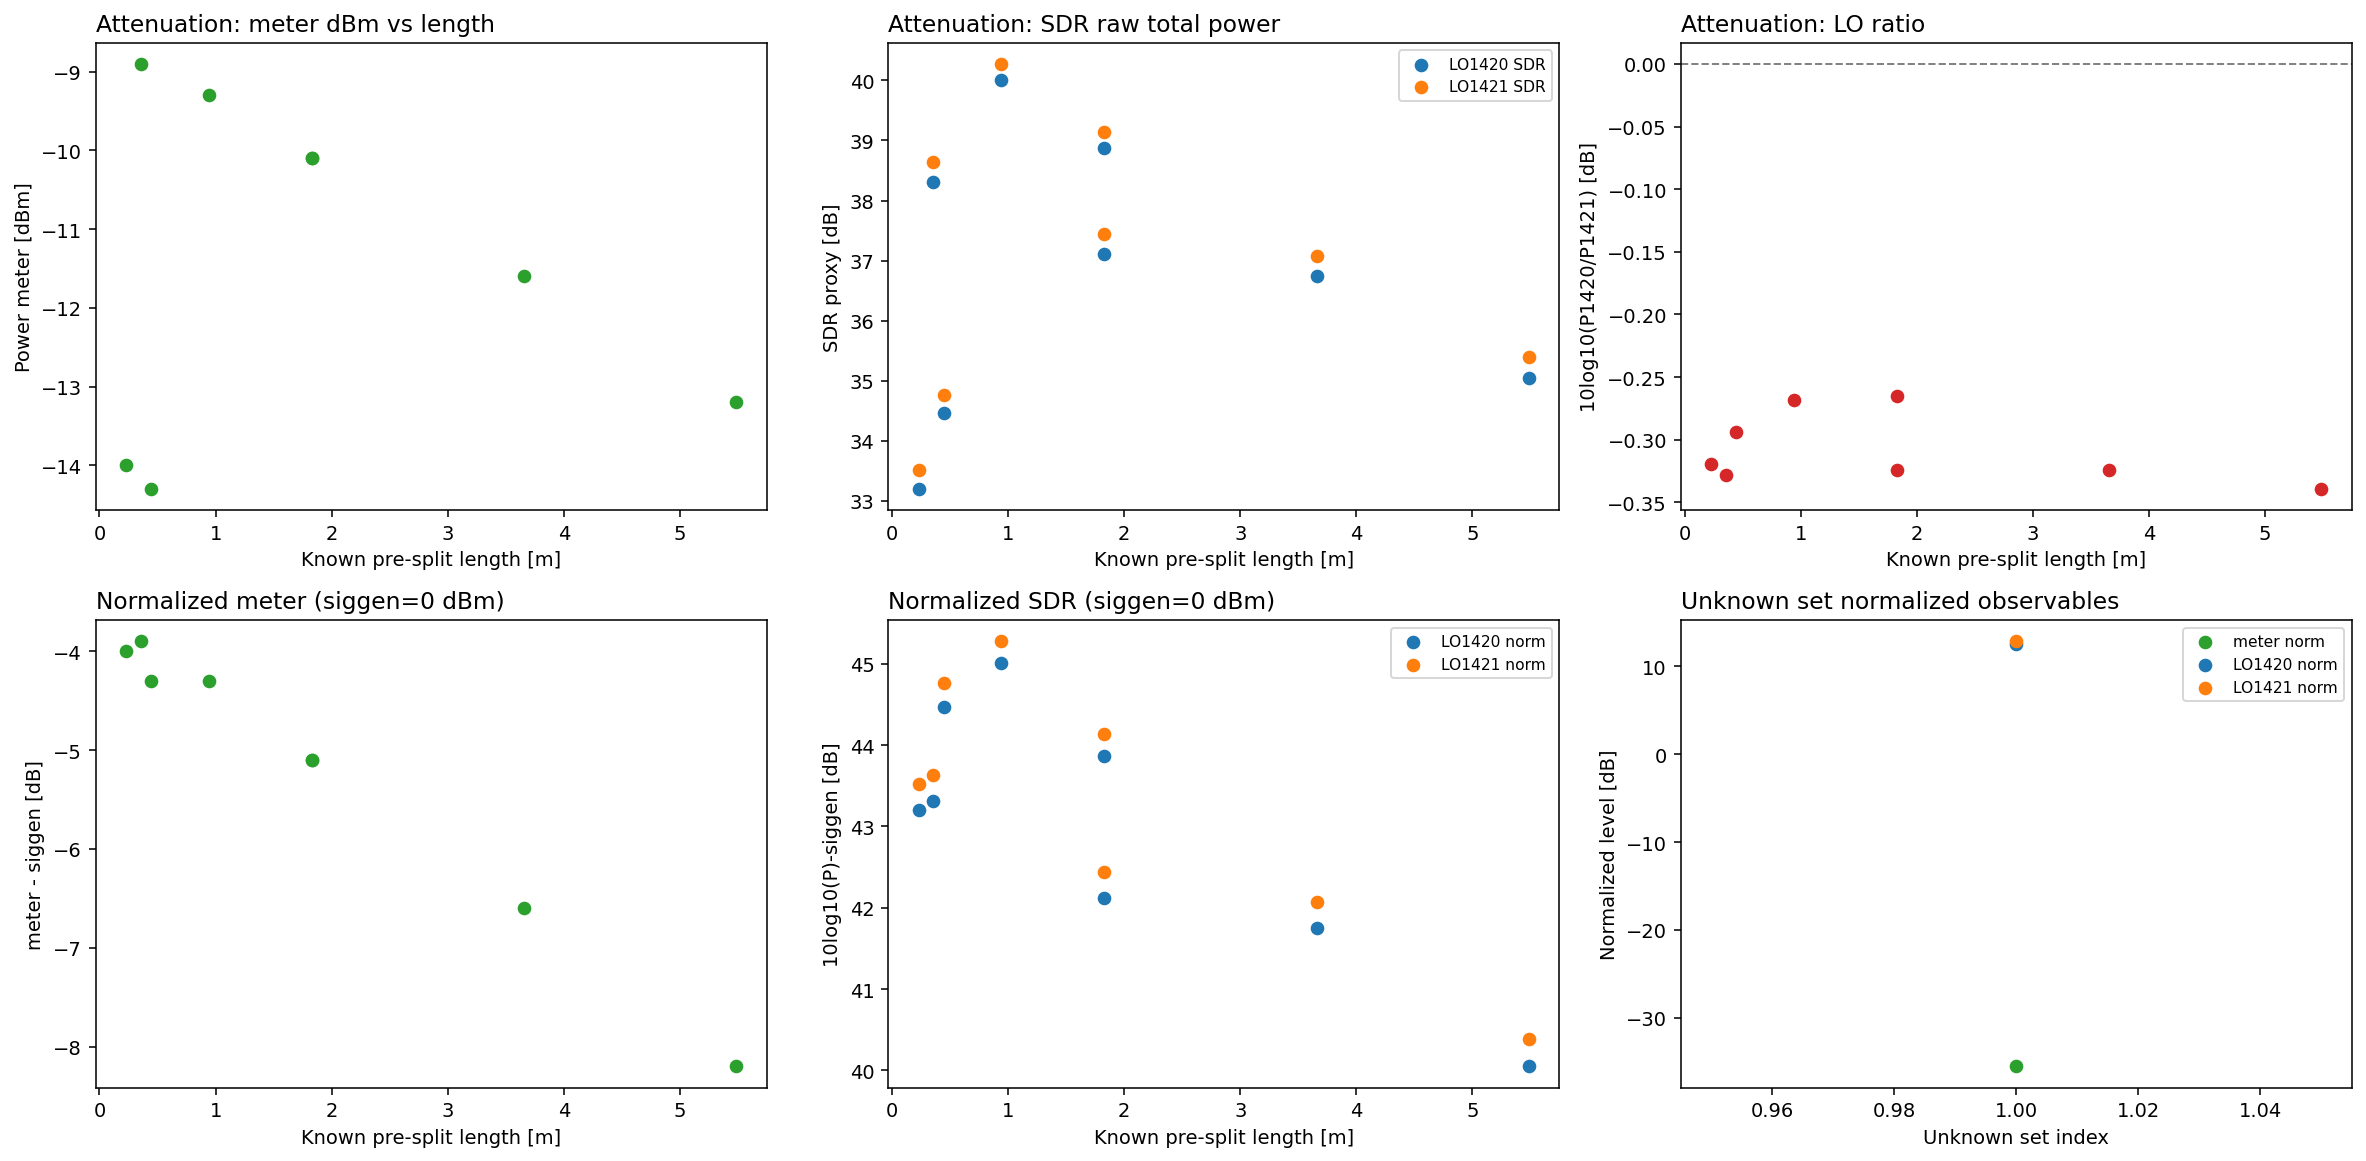

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8.4), dpi=140)

axes[0, 0].scatter(L, meter_dbm, color='C2')
axes[0, 0].set_title('Attenuation: meter dBm vs length', loc='left')
axes[0, 0].set_xlabel('Known pre-split length [m]')
axes[0, 0].set_ylabel('Power meter [dBm]')

axes[0, 1].scatter(L, y1420_db, color='C0', label='LO1420 SDR')
axes[0, 1].scatter(L, y1421_db, color='C1', label='LO1421 SDR')
axes[0, 1].set_title('Attenuation: SDR raw total power', loc='left')
axes[0, 1].set_xlabel('Known pre-split length [m]')
axes[0, 1].set_ylabel('SDR proxy [dB]')
axes[0, 1].legend(fontsize=8)

axes[0, 2].scatter(L, ratio_db, color='C3')
axes[0, 2].axhline(0, color='gray', lw=1, ls='--')
axes[0, 2].set_title('Attenuation: LO ratio', loc='left')
axes[0, 2].set_xlabel('Known pre-split length [m]')
axes[0, 2].set_ylabel('10log10(P1420/P1421) [dB]')

axes[1, 0].scatter(L, meter_norm, color='C2')
axes[1, 0].set_title('Normalized meter (siggen=0 dBm)', loc='left')
axes[1, 0].set_xlabel('Known pre-split length [m]')
axes[1, 0].set_ylabel('meter - siggen [dB]')

axes[1, 1].scatter(L, y1420_norm, color='C0', label='LO1420 norm')
axes[1, 1].scatter(L, y1421_norm, color='C1', label='LO1421 norm')
axes[1, 1].set_title('Normalized SDR (siggen=0 dBm)', loc='left')
axes[1, 1].set_xlabel('Known pre-split length [m]')
axes[1, 1].set_ylabel('10log10(P)-siggen [dB]')
axes[1, 1].legend(fontsize=8)

u_idx = np.arange(1, len(unknown_rows) + 1)
axes[1, 2].scatter(u_idx, u_meter_norm, color='C2', label='meter norm')
axes[1, 2].scatter(u_idx, u_y1420_norm, color='C0', label='LO1420 norm')
axes[1, 2].scatter(u_idx, u_y1421_norm, color='C1', label='LO1421 norm')
axes[1, 2].set_title('Unknown set normalized observables', loc='left')
axes[1, 2].set_xlabel('Unknown set index')
axes[1, 2].set_ylabel('Normalized level [dB]')
axes[1, 2].legend(fontsize=8)

fig.tight_layout()
plt.show()


In [6]:
def fit_shared_linear(L: np.ndarray, y0: np.ndarray, y1: np.ndarray) -> dict:
    L = np.asarray(L, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    y1 = np.asarray(y1, dtype=float)
    n = L.size

    y = np.concatenate([y0, y1])
    X = np.zeros((2*n, 3), dtype=float)
    X[:n, 0] = 1.0
    X[:n, 2] = -L
    X[n:, 1] = 1.0
    X[n:, 2] = -L

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B0, B1, alpha = beta
    yhat = X @ beta
    resid = y - yhat

    rss = float(np.sum(resid**2))
    n_obs = y.size
    dof = n_obs - beta.size
    sigma2 = rss / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((3, 3), np.nan)
    sig = np.sqrt(np.diag(cov))

    var_delta = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    sig_delta = np.sqrt(var_delta) if var_delta >= 0 else np.nan
    aic, bic = aic_bic_from_rss(rss, n_obs, 3)

    return {
        'B1420_db': float(B0),
        'B1421_db': float(B1),
        'alpha_db_per_m': float(alpha),
        'deltaB_db': float(B0 - B1),
        'sigma_B1420_db': float(sig[0]),
        'sigma_B1421_db': float(sig[1]),
        'sigma_alpha_db_per_m': float(sig[2]),
        'sigma_deltaB_db': float(sig_delta),
        'rss': rss,
        'rmse': float(np.sqrt(np.mean(resid**2))),
        'aic': aic,
        'bic': bic,
        'residuals': resid,
    }


def fit_single_linear(L: np.ndarray, y: np.ndarray) -> dict:
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)

    X = np.column_stack([np.ones_like(L), -L])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B, alpha = beta
    yhat = X @ beta
    resid = y - yhat

    rss = float(np.sum(resid**2))
    n_obs = y.size
    dof = n_obs - beta.size
    sigma2 = rss / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((2, 2), np.nan)
    sig = np.sqrt(np.diag(cov))
    aic, bic = aic_bic_from_rss(rss, n_obs, 2)

    return {
        'B_db': float(B),
        'alpha_db_per_m': float(alpha),
        'sigma_B_db': float(sig[0]),
        'sigma_alpha_db_per_m': float(sig[1]),
        'rss': rss,
        'rmse': float(np.sqrt(np.mean(resid**2))),
        'aic': aic,
        'bic': bic,
        'residuals': resid,
    }


def _shared_ripple_fit_at_k(L: np.ndarray, y0: np.ndarray, y1: np.ndarray, k: float):
    c = np.cos(k * L)
    s = np.sin(k * L)
    n = L.size

    X = np.zeros((2*n, 7), dtype=float)
    y = np.concatenate([y0, y1])

    X[:n, 0] = 1.0
    X[:n, 2] = -L
    X[:n, 3] = c
    X[:n, 4] = s

    X[n:, 1] = 1.0
    X[n:, 2] = -L
    X[n:, 5] = c
    X[n:, 6] = s

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    yhat = X @ beta
    resid = y - yhat
    rss = float(np.sum(resid**2))
    return beta, yhat, resid, rss


def fit_shared_ripple(L: np.ndarray, y0: np.ndarray, y1: np.ndarray, k_grid: np.ndarray | None = None) -> dict:
    L = np.asarray(L, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    y1 = np.asarray(y1, dtype=float)

    if k_grid is None:
        k_grid = np.linspace(2*np.pi / K_PERIOD_MAX_M, 2*np.pi / K_PERIOD_MIN_M, K_GRID_N)

    rss_grid = np.full(k_grid.shape, np.nan, dtype=float)
    best = None

    for i, k in enumerate(k_grid):
        try:
            beta, yhat, resid, rss = _shared_ripple_fit_at_k(L, y0, y1, float(k))
        except np.linalg.LinAlgError:
            continue
        rss_grid[i] = rss
        if best is None or rss < best['rss']:
            best = {'k': float(k), 'beta': beta, 'yhat': yhat, 'resid': resid, 'rss': float(rss)}

    if best is None:
        raise RuntimeError('Ripple fit failed for all k values.')

    B0, B1, alpha, C0, D0, C1, D1 = best['beta']
    A0 = float(np.hypot(C0, D0))
    A1 = float(np.hypot(C1, D1))
    phi0 = float(np.arctan2(-D0, C0))
    phi1 = float(np.arctan2(-D1, C1))

    n_obs = 2 * L.size
    n_params_eff = 8
    dof = n_obs - n_params_eff
    sigma2 = best['rss'] / dof if dof > 0 else np.nan

    c = np.cos(best['k'] * L)
    s = np.sin(best['k'] * L)
    X = np.zeros((2*L.size, 7), dtype=float)
    X[:L.size, 0] = 1.0
    X[:L.size, 2] = -L
    X[:L.size, 3] = c
    X[:L.size, 4] = s
    X[L.size:, 1] = 1.0
    X[L.size:, 2] = -L
    X[L.size:, 5] = c
    X[L.size:, 6] = s

    cov_lin = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((7, 7), np.nan)
    sigma_alpha = float(np.sqrt(cov_lin[2, 2])) if np.isfinite(cov_lin[2, 2]) and cov_lin[2, 2] >= 0 else np.nan
    aic, bic = aic_bic_from_rss(best['rss'], n_obs, n_params_eff)

    return {
        'B1420_db': float(B0),
        'B1421_db': float(B1),
        'alpha_db_per_m': float(alpha),
        'sigma_alpha_db_per_m': sigma_alpha,
        'k_rad_per_m': float(best['k']),
        'period_m': float(2*np.pi / best['k']),
        'A1420_db': A0,
        'A1421_db': A1,
        'phi1420_rad': phi0,
        'phi1421_rad': phi1,
        'deltaB_db': float(B0 - B1),
        'rss': float(best['rss']),
        'rmse': float(np.sqrt(np.mean(best['resid']**2))),
        'aic': aic,
        'bic': bic,
        'k_grid': k_grid,
        'rss_grid': rss_grid,
    }


def fit_single_ripple(L: np.ndarray, y: np.ndarray, k_grid: np.ndarray | None = None) -> dict:
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)

    if k_grid is None:
        k_grid = np.linspace(2*np.pi / K_PERIOD_MAX_M, 2*np.pi / K_PERIOD_MIN_M, K_GRID_N)

    best = None
    rss_grid = np.full(k_grid.shape, np.nan, dtype=float)
    for i, k in enumerate(k_grid):
        c = np.cos(k * L)
        s = np.sin(k * L)
        X = np.column_stack([np.ones_like(L), -L, c, s])
        try:
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        except np.linalg.LinAlgError:
            continue

        yhat = X @ beta
        resid = y - yhat
        rss = float(np.sum(resid**2))
        rss_grid[i] = rss
        if best is None or rss < best['rss']:
            best = {'k': float(k), 'beta': beta, 'yhat': yhat, 'resid': resid, 'rss': rss}

    if best is None:
        raise RuntimeError('Single ripple fit failed for all k.')

    B, alpha, C, D = best['beta']
    A = float(np.hypot(C, D))
    phi = float(np.arctan2(-D, C))

    n_obs = y.size
    n_params_eff = 5
    aic, bic = aic_bic_from_rss(best['rss'], n_obs, n_params_eff)

    return {
        'B_db': float(B),
        'alpha_db_per_m': float(alpha),
        'k_rad_per_m': float(best['k']),
        'period_m': float(2*np.pi / best['k']),
        'A_db': A,
        'phi_rad': phi,
        'rss': float(best['rss']),
        'rmse': float(np.sqrt(np.mean(best['resid']**2))),
        'aic': aic,
        'bic': bic,
        'k_grid': k_grid,
        'rss_grid': rss_grid,
    }


def bootstrap_linear_shared_params(L, y0, y1, n_boot=BOOTSTRAP_LINEAR_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(L)
    b0 = []
    b1 = []
    alpha = []
    delta = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Ls = L[idx]
        if np.unique(Ls).size < 2:
            continue
        f = fit_shared_linear(Ls, y0[idx], y1[idx])
        b0.append(f['B1420_db'])
        b1.append(f['B1421_db'])
        alpha.append(f['alpha_db_per_m'])
        delta.append(f['deltaB_db'])
    return np.array(b0, float), np.array(b1, float), np.array(alpha, float), np.array(delta, float)


def bootstrap_linear_single_params(L, y, n_boot=BOOTSTRAP_LINEAR_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(L)
    b = []
    alpha = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Ls = L[idx]
        if np.unique(Ls).size < 2:
            continue
        f = fit_single_linear(Ls, y[idx])
        b.append(f['B_db'])
        alpha.append(f['alpha_db_per_m'])
    return np.array(b, float), np.array(alpha, float)


def bootstrap_ripple_shared_alpha_k(L, y0, y1, k_grid, n_boot=BOOTSTRAP_RIPPLE_N, seed=BOOTSTRAP_SEED):
    rng = np.random.default_rng(seed)
    n = len(L)
    alpha = []
    kvals = []
    fail = 0
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        Ls = L[idx]
        if np.unique(Ls).size < 2:
            fail += 1
            continue
        try:
            f = fit_shared_ripple(Ls, y0[idx], y1[idx], k_grid=k_grid)
        except Exception:
            fail += 1
            continue
        alpha.append(f['alpha_db_per_m'])
        kvals.append(f['k_rad_per_m'])
    return np.array(alpha, float), np.array(kvals, float), fail


In [7]:
k_grid = np.linspace(2*np.pi / K_PERIOD_MAX_M, 2*np.pi / K_PERIOD_MIN_M, K_GRID_N)

fit_lin_sdr = fit_shared_linear(L, y1420_norm, y1421_norm)
fit_lin_meter = fit_single_linear(L, meter_norm)

fit_rip_sdr = fit_shared_ripple(L, y1420_norm, y1421_norm, k_grid=k_grid)
fit_rip_meter = fit_single_ripple(L, meter_norm, k_grid=k_grid)

b0_bs, b1_bs, alpha_lin_bs, delta_lin_bs = bootstrap_linear_shared_params(L, y1420_norm, y1421_norm)
bm_bs, alpha_meter_bs = bootstrap_linear_single_params(L, meter_norm)
alpha_rip_bs, k_rip_bs, n_fail_rip_bs = bootstrap_ripple_shared_alpha_k(L, y1420_norm, y1421_norm, k_grid=k_grid)

print('=== Fit quality (normalized SDR) ===')
print(f"Linear : RMSE={fit_lin_sdr['rmse']:.4f} dB, AIC={fit_lin_sdr['aic']:.3f}, BIC={fit_lin_sdr['bic']:.3f}")
print(f"Ripple : RMSE={fit_rip_sdr['rmse']:.4f} dB, AIC={fit_rip_sdr['aic']:.3f}, BIC={fit_rip_sdr['bic']:.3f}")
print()
print('=== Fit quality (normalized meter) ===')
print(f"Linear : RMSE={fit_lin_meter['rmse']:.4f} dB, AIC={fit_lin_meter['aic']:.3f}, BIC={fit_lin_meter['bic']:.3f}")
print(f"Ripple : RMSE={fit_rip_meter['rmse']:.4f} dB, AIC={fit_rip_meter['aic']:.3f}, BIC={fit_rip_meter['bic']:.3f}")
print()
print('=== Shared linear slope on pre-split length ===')
print(f"alpha (SDR)  = {fit_lin_sdr['alpha_db_per_m']:.6f} +/- {fit_lin_sdr['sigma_alpha_db_per_m']:.6f} dB/m")
print(f"alpha (meter)= {fit_lin_meter['alpha_db_per_m']:.6f} +/- {fit_lin_meter['sigma_alpha_db_per_m']:.6f} dB/m")
print()
print('=== Shared ripple parameters (SDR) ===')
print(f"alpha = {fit_rip_sdr['alpha_db_per_m']:.6f} dB/m")
print(f"k     = {fit_rip_sdr['k_rad_per_m']:.6f} rad/m (period={fit_rip_sdr['period_m']:.4f} m)")
print(f"A1420 = {fit_rip_sdr['A1420_db']:.4f} dB, A1421 = {fit_rip_sdr['A1421_db']:.4f} dB")
print()
print('=== Bootstrap counts ===')
print(f'Linear shared valid: {alpha_lin_bs.size}/{BOOTSTRAP_LINEAR_N}')
print(f'Linear meter  valid: {alpha_meter_bs.size}/{BOOTSTRAP_LINEAR_N}')
print(f'Ripple shared valid: {alpha_rip_bs.size}/{BOOTSTRAP_RIPPLE_N} (failed {n_fail_rip_bs})')


=== Fit quality (normalized SDR) ===
Linear : RMSE=0.7953 dB, AIC=-1.330, BIC=0.988
Ripple : RMSE=0.4826 dB, AIC=-7.315, BIC=-1.134

=== Fit quality (normalized meter) ===
Linear : RMSE=0.1242 dB, AIC=-29.378, BIC=-29.219
Ripple : RMSE=0.0158 dB, AIC=-56.344, BIC=-55.946

=== Shared linear slope on pre-split length ===
alpha (SDR)  = 0.728112 +/- 0.126931 dB/m
alpha (meter)= 0.803730 +/- 0.029172 dB/m

=== Shared ripple parameters (SDR) ===
alpha = 0.692419 dB/m
k     = 15.523801 rad/m (period=0.4047 m)
A1420 = 1.3209 dB, A1421 = 1.2837 dB

=== Bootstrap counts ===
Linear shared valid: 10000/10000
Linear meter  valid: 10000/10000
Ripple shared valid: 1000/1000 (failed 0)


In [8]:
def lin_unknown_lengths_from_obs(y0_obs, y1_obs, ym_obs, fit_sdr, fit_meter):
    alpha_sdr = fit_sdr['alpha_db_per_m']
    alpha_m = fit_meter['alpha_db_per_m']

    L0 = (fit_sdr['B1420_db'] - y0_obs) / alpha_sdr
    L1 = (fit_sdr['B1421_db'] - y1_obs) / alpha_sdr
    Lm = (fit_meter['B_db'] - ym_obs) / alpha_m
    L_sdr_mean = 0.5 * (L0 + L1)
    L_all_mean = (L0 + L1 + Lm) / 3.0
    return L0, L1, Lm, L_sdr_mean, L_all_mean


def lin_unknown_bootstrap(y0_obs, y1_obs, ym_obs, b0_bs, b1_bs, alpha_sdr_bs, bm_bs, alpha_m_bs):
    n = min(len(b0_bs), len(b1_bs), len(alpha_sdr_bs), len(bm_bs), len(alpha_m_bs))
    if n == 0:
        return np.array([], float), np.array([], float), np.array([], float), np.array([], float), np.array([], float)

    b0 = b0_bs[:n]
    b1 = b1_bs[:n]
    a = alpha_sdr_bs[:n]
    bm = bm_bs[:n]
    am = alpha_m_bs[:n]

    good = (np.abs(a) > 1e-8) & (np.abs(am) > 1e-8)
    if not np.any(good):
        return np.array([], float), np.array([], float), np.array([], float), np.array([], float), np.array([], float)

    b0 = b0[good]
    b1 = b1[good]
    a = a[good]
    bm = bm[good]
    am = am[good]

    L0 = (b0 - y0_obs) / a
    L1 = (b1 - y1_obs) / a
    Lm = (bm - ym_obs) / am
    L_sdr = 0.5 * (L0 + L1)
    L_all = (L0 + L1 + Lm) / 3.0
    return L0, L1, Lm, L_sdr, L_all


def model_ripple_value(Lv, B, alpha, A, k, phi):
    return B - alpha * Lv + A * np.cos(k * Lv + phi)


def best_length_ripple_pair(y0_obs, y1_obs, fit_sdr, L_grid):
    y0_model = model_ripple_value(L_grid, fit_sdr['B1420_db'], fit_sdr['alpha_db_per_m'], fit_sdr['A1420_db'], fit_sdr['k_rad_per_m'], fit_sdr['phi1420_rad'])
    y1_model = model_ripple_value(L_grid, fit_sdr['B1421_db'], fit_sdr['alpha_db_per_m'], fit_sdr['A1421_db'], fit_sdr['k_rad_per_m'], fit_sdr['phi1421_rad'])
    rss = (y0_obs - y0_model) ** 2 + (y1_obs - y1_model) ** 2

    i_best = int(np.argmin(rss))
    L_best = float(L_grid[i_best])
    rss_best = float(rss[i_best])

    order = np.argsort(rss)
    i_second = None
    for j in order[1:]:
        if abs(float(L_grid[j]) - L_best) >= 0.20:
            i_second = int(j)
            break

    if i_second is None:
        ambiguous = False
        L_second = np.nan
        rss_second = np.nan
    else:
        L_second = float(L_grid[i_second])
        rss_second = float(rss[i_second])
        ambiguous = (rss_best > 0) and (rss_second / rss_best <= 1.05)

    return {
        'L_best': L_best,
        'rss_best': rss_best,
        'L_second': L_second,
        'rss_second': rss_second,
        'ambiguous': ambiguous,
        'rss_curve': rss,
    }


def ci_tuple(samples: np.ndarray):
    (q16, q50, q84), (q025, q975) = q68_95(samples)
    return {
        'q16': float(q16), 'q50': float(q50), 'q84': float(q84),
        'q025': float(q025), 'q975': float(q975),
    }


unknown_reports = []
L_grid = np.linspace(L_SEARCH_MIN_M, L_SEARCH_MAX_M, L_SEARCH_N)

for i, row in enumerate(unknown_rows):
    y0_obs = u_y1420_norm[i]
    y1_obs = u_y1421_norm[i]
    ym_obs = u_meter_norm[i]

    L0_lin, L1_lin, Lm_lin, Ls_lin, Lall_lin = lin_unknown_lengths_from_obs(
        y0_obs,
        y1_obs,
        ym_obs,
        fit_lin_sdr,
        fit_lin_meter,
    )

    L0_bs, L1_bs, Lm_bs, Ls_bs, Lall_bs = lin_unknown_bootstrap(
        y0_obs,
        y1_obs,
        ym_obs,
        b0_bs,
        b1_bs,
        alpha_lin_bs,
        bm_bs,
        alpha_meter_bs,
    )

    rip_pair = best_length_ripple_pair(y0_obs, y1_obs, fit_rip_sdr, L_grid)

    report = {
        'set_id': row['set_id'],
        'y0_obs': float(y0_obs),
        'y1_obs': float(y1_obs),
        'ym_obs': float(ym_obs),
        'L0_lin_total_m': float(L0_lin),
        'L1_lin_total_m': float(L1_lin),
        'Lm_lin_total_m': float(Lm_lin),
        'Ls_lin_total_m': float(Ls_lin),
        'Lall_lin_total_m': float(Lall_lin),
        'L0_lin_unknown_m': float(L0_lin - UNKNOWN_LEAD_LENGTH_M),
        'L1_lin_unknown_m': float(L1_lin - UNKNOWN_LEAD_LENGTH_M),
        'Lm_lin_unknown_m': float(Lm_lin - UNKNOWN_LEAD_LENGTH_M),
        'Ls_lin_unknown_m': float(Ls_lin - UNKNOWN_LEAD_LENGTH_M),
        'Lall_lin_unknown_m': float(Lall_lin - UNKNOWN_LEAD_LENGTH_M),
        'L_sdr_ripple_total_m': float(rip_pair['L_best']),
        'L_sdr_ripple_unknown_m': float(rip_pair['L_best'] - UNKNOWN_LEAD_LENGTH_M),
        'ripple_ambiguous': bool(rip_pair['ambiguous']),
        'ripple_second_total_m': float(rip_pair['L_second']),
    }

    if Ls_bs.size:
        report['Ls_lin_total_ci'] = ci_tuple(Ls_bs)
        report['Ls_lin_unknown_ci'] = ci_tuple(Ls_bs - UNKNOWN_LEAD_LENGTH_M)
    if Lall_bs.size:
        report['Lall_lin_total_ci'] = ci_tuple(Lall_bs)
        report['Lall_lin_unknown_ci'] = ci_tuple(Lall_bs - UNKNOWN_LEAD_LENGTH_M)

    unknown_reports.append(report)

for rep in unknown_reports:
    print(f"=== Unknown set {rep['set_id']:04d} ===")
    print(f"Linear total length [m]: LO1420={rep['L0_lin_total_m']:.4f}, LO1421={rep['L1_lin_total_m']:.4f}, meter={rep['Lm_lin_total_m']:.4f}")
    print(f"Linear total (SDR mean) [m]: {rep['Ls_lin_total_m']:.4f}")
    print(f"Linear unknown (SDR mean - 12 ft) [m]: {rep['Ls_lin_unknown_m']:.4f}")
    if 'Ls_lin_unknown_ci' in rep:
        ci = rep['Ls_lin_unknown_ci']
        print(
            'Linear unknown bootstrap (SDR mean) [16,50,84] [m]: '
            f"[{ci['q16']:.4f}, {ci['q50']:.4f}, {ci['q84']:.4f}]"
        )
        print(
            'Linear unknown bootstrap 95% [m]: '
            f"[{ci['q025']:.4f}, {ci['q975']:.4f}]"
        )
    print(f"Ripple total (SDR pair) [m]: {rep['L_sdr_ripple_total_m']:.4f}")
    print(f"Ripple unknown (minus 12 ft) [m]: {rep['L_sdr_ripple_unknown_m']:.4f}")
    if rep['ripple_ambiguous']:
        print(f"Ripple note: second near-minimum at {rep['ripple_second_total_m']:.4f} m")
    print()


=== Unknown set 0001 ===
Linear total length [m]: LO1420=43.7271, LO1421=43.7059, meter=39.5611
Linear total (SDR mean) [m]: 43.7165
Linear unknown (SDR mean - 12 ft) [m]: 40.0589
Linear unknown bootstrap (SDR mean) [16,50,84] [m]: [33.8624, 40.4167, 50.2729]
Linear unknown bootstrap 95% [m]: [-14.1187, 87.6437]
Ripple total (SDR pair) [m]: 29.8550
Ripple unknown (minus 12 ft) [m]: 26.1974



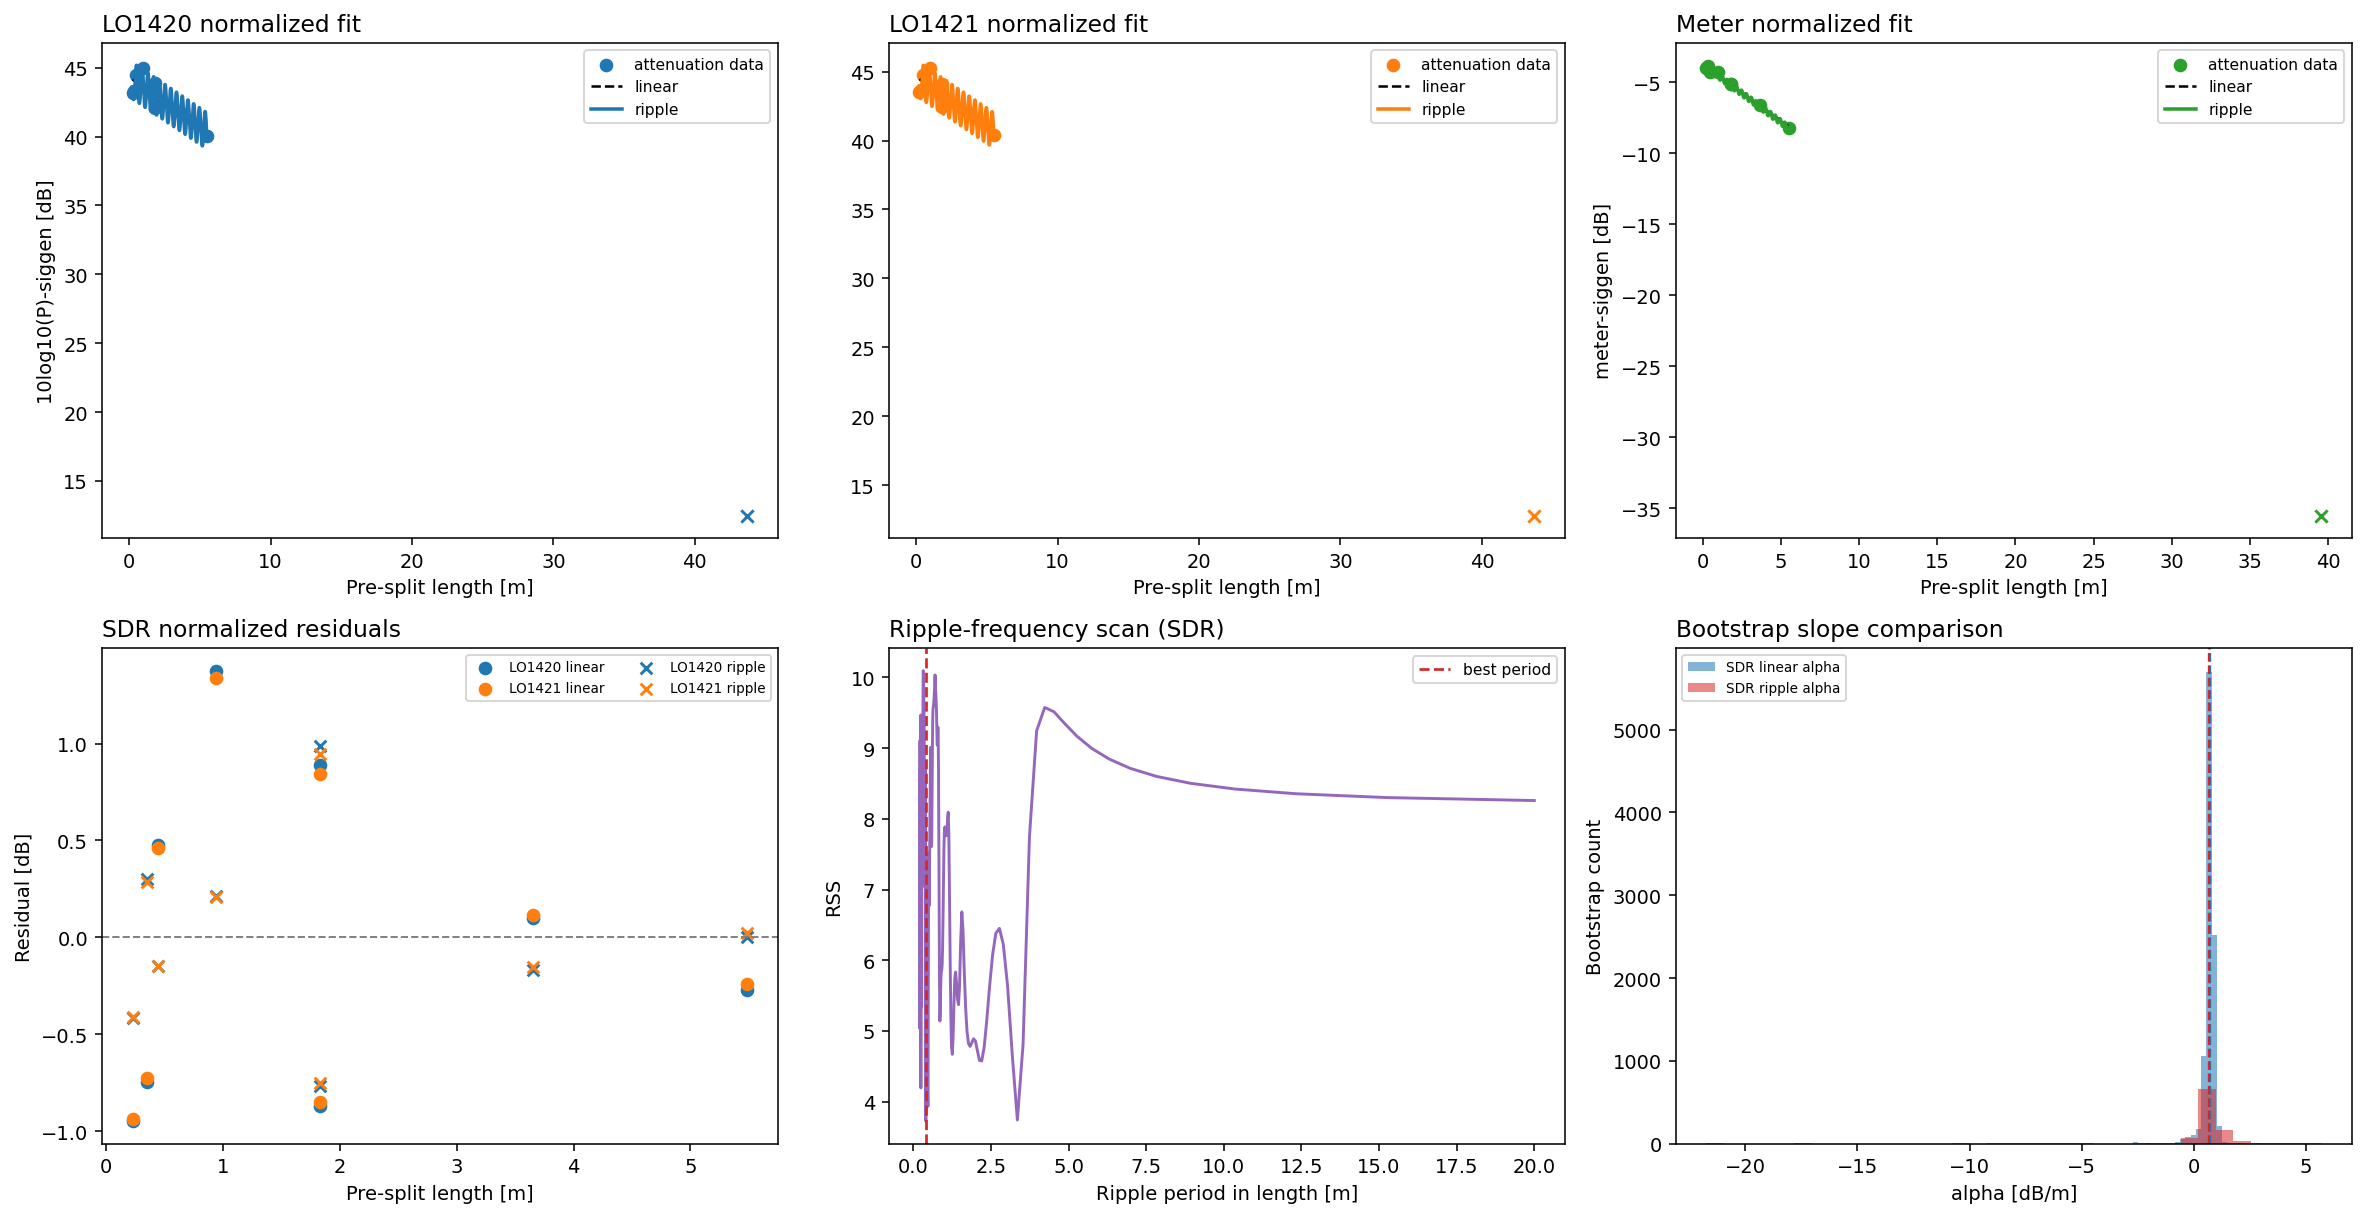

In [9]:
L_line = np.linspace(float(L.min()), float(L.max()), 800)

# Linear predictions in normalized space.
y0_lin = fit_lin_sdr['B1420_db'] - fit_lin_sdr['alpha_db_per_m'] * L_line
y1_lin = fit_lin_sdr['B1421_db'] - fit_lin_sdr['alpha_db_per_m'] * L_line
ym_lin = fit_lin_meter['B_db'] - fit_lin_meter['alpha_db_per_m'] * L_line

# Ripple predictions in normalized space.
y0_rip = fit_rip_sdr['B1420_db'] - fit_rip_sdr['alpha_db_per_m'] * L_line + fit_rip_sdr['A1420_db'] * np.cos(fit_rip_sdr['k_rad_per_m'] * L_line + fit_rip_sdr['phi1420_rad'])
y1_rip = fit_rip_sdr['B1421_db'] - fit_rip_sdr['alpha_db_per_m'] * L_line + fit_rip_sdr['A1421_db'] * np.cos(fit_rip_sdr['k_rad_per_m'] * L_line + fit_rip_sdr['phi1421_rad'])
ym_rip = fit_rip_meter['B_db'] - fit_rip_meter['alpha_db_per_m'] * L_line + fit_rip_meter['A_db'] * np.cos(fit_rip_meter['k_rad_per_m'] * L_line + fit_rip_meter['phi_rad'])

fig, axes = plt.subplots(2, 3, figsize=(17, 8.8), dpi=140)

# LO1420 normalized fit.
axes[0, 0].scatter(L, y1420_norm, color='C0', label='attenuation data')
axes[0, 0].plot(L_line, y0_lin, color='k', lw=1.3, ls='--', label='linear')
axes[0, 0].plot(L_line, y0_rip, color='C0', lw=1.8, label='ripple')
for rep in unknown_reports:
    axes[0, 0].scatter(rep['L0_lin_total_m'], rep['y0_obs'], color='C0', marker='x', s=40)
axes[0, 0].set_title('LO1420 normalized fit', loc='left')
axes[0, 0].set_xlabel('Pre-split length [m]')
axes[0, 0].set_ylabel('10log10(P)-siggen [dB]')
axes[0, 0].legend(fontsize=8)

# LO1421 normalized fit.
axes[0, 1].scatter(L, y1421_norm, color='C1', label='attenuation data')
axes[0, 1].plot(L_line, y1_lin, color='k', lw=1.3, ls='--', label='linear')
axes[0, 1].plot(L_line, y1_rip, color='C1', lw=1.8, label='ripple')
for rep in unknown_reports:
    axes[0, 1].scatter(rep['L1_lin_total_m'], rep['y1_obs'], color='C1', marker='x', s=40)
axes[0, 1].set_title('LO1421 normalized fit', loc='left')
axes[0, 1].set_xlabel('Pre-split length [m]')
axes[0, 1].legend(fontsize=8)

# Meter normalized fit.
axes[0, 2].scatter(L, meter_norm, color='C2', label='attenuation data')
axes[0, 2].plot(L_line, ym_lin, color='k', lw=1.3, ls='--', label='linear')
axes[0, 2].plot(L_line, ym_rip, color='C2', lw=1.8, label='ripple')
for rep in unknown_reports:
    axes[0, 2].scatter(rep['Lm_lin_total_m'], rep['ym_obs'], color='C2', marker='x', s=40)
axes[0, 2].set_title('Meter normalized fit', loc='left')
axes[0, 2].set_xlabel('Pre-split length [m]')
axes[0, 2].set_ylabel('meter-siggen [dB]')
axes[0, 2].legend(fontsize=8)

# SDR residuals linear vs ripple.
res0_lin = y1420_norm - (fit_lin_sdr['B1420_db'] - fit_lin_sdr['alpha_db_per_m'] * L)
res1_lin = y1421_norm - (fit_lin_sdr['B1421_db'] - fit_lin_sdr['alpha_db_per_m'] * L)
res0_rip = y1420_norm - (fit_rip_sdr['B1420_db'] - fit_rip_sdr['alpha_db_per_m'] * L + fit_rip_sdr['A1420_db'] * np.cos(fit_rip_sdr['k_rad_per_m'] * L + fit_rip_sdr['phi1420_rad']))
res1_rip = y1421_norm - (fit_rip_sdr['B1421_db'] - fit_rip_sdr['alpha_db_per_m'] * L + fit_rip_sdr['A1421_db'] * np.cos(fit_rip_sdr['k_rad_per_m'] * L + fit_rip_sdr['phi1421_rad']))

axes[1, 0].axhline(0, color='gray', ls='--', lw=1)
axes[1, 0].scatter(L, res0_lin, color='C0', marker='o', label='LO1420 linear')
axes[1, 0].scatter(L, res1_lin, color='C1', marker='o', label='LO1421 linear')
axes[1, 0].scatter(L, res0_rip, color='C0', marker='x', label='LO1420 ripple')
axes[1, 0].scatter(L, res1_rip, color='C1', marker='x', label='LO1421 ripple')
axes[1, 0].set_title('SDR normalized residuals', loc='left')
axes[1, 0].set_xlabel('Pre-split length [m]')
axes[1, 0].set_ylabel('Residual [dB]')
axes[1, 0].legend(fontsize=7, ncol=2)

# Ripple k scan.
period_grid = 2 * np.pi / fit_rip_sdr['k_grid']
axes[1, 1].plot(period_grid, fit_rip_sdr['rss_grid'], color='C4')
axes[1, 1].axvline(fit_rip_sdr['period_m'], color='C3', ls='--', lw=1.4, label='best period')
axes[1, 1].set_xlabel('Ripple period in length [m]')
axes[1, 1].set_ylabel('RSS')
axes[1, 1].set_title('Ripple-frequency scan (SDR)', loc='left')
axes[1, 1].legend(fontsize=8)

# Bootstrap slope comparison.
axes[1, 2].hist(alpha_lin_bs, bins=35, alpha=0.55, color='C0', label='SDR linear alpha')
axes[1, 2].hist(alpha_rip_bs, bins=35, alpha=0.55, color='C3', label='SDR ripple alpha')
axes[1, 2].axvline(fit_lin_sdr['alpha_db_per_m'], color='C0', ls='--', lw=1.2)
axes[1, 2].axvline(fit_rip_sdr['alpha_db_per_m'], color='C3', ls='--', lw=1.2)
axes[1, 2].set_xlabel('alpha [dB/m]')
axes[1, 2].set_ylabel('Bootstrap count')
axes[1, 2].set_title('Bootstrap slope comparison', loc='left')
axes[1, 2].legend(fontsize=7)

fig.tight_layout()
plt.show()


In [10]:
def ci_str(lo, hi):
    return f'[{lo:.6f}, {hi:.6f}]'

(a16, a50, a84), (a025, a975) = q68_95(alpha_lin_bs)
(ar16, ar50, ar84), (ar025, ar975) = q68_95(alpha_rip_bs)
(k16, k50, k84), (k025, k975) = q68_95(k_rip_bs)
(m16, m50, m84), (m025, m975) = q68_95(alpha_meter_bs)
(da16, da50, da84), (da025, da975) = q68_95(delta_lin_bs)

alpha_near_zero_eps = 0.05
alpha_near_zero_frac = float(np.mean(np.abs(alpha_lin_bs) <= alpha_near_zero_eps)) if alpha_lin_bs.size else np.nan
alpha_ci_crosses_zero = bool(np.isfinite(a025) and np.isfinite(a975) and (a025 <= 0.0 <= a975))

print('=== Final report summary ===')
print(f'Attenuation sets used: {len(atten_rows)}')
print(f'Unknown sets used    : {len(unknown_rows)}')
print(f'Excluded anomaly lengths [m]: {EXCLUDE_LENGTHS_M} +/- {EXCLUDE_LENGTH_TOL_M}')
print(f'Unknown fixed lead [m]      : {UNKNOWN_LEAD_LENGTH_M:.4f}')
print()
print('Normalized shared linear SDR model:')
print(f"  y1420 = {fit_lin_sdr['B1420_db']:.6f} - {fit_lin_sdr['alpha_db_per_m']:.6f} * L")
print(f"  y1421 = {fit_lin_sdr['B1421_db']:.6f} - {fit_lin_sdr['alpha_db_per_m']:.6f} * L")
print(f"  alpha OLS = {fit_lin_sdr['alpha_db_per_m']:.6f} +/- {fit_lin_sdr['sigma_alpha_db_per_m']:.6f} dB/m")
print(f"  alpha bootstrap 95% CI = {ci_str(a025, a975)} dB/m")
print(f"  deltaB OLS = {fit_lin_sdr['deltaB_db']:.6f} +/- {fit_lin_sdr['sigma_deltaB_db']:.6f} dB")
print(f"  deltaB bootstrap 95% CI = {ci_str(da025, da975)} dB")
if alpha_ci_crosses_zero:
    print('  WARNING: linear alpha 95% CI crosses 0 dB/m; inverse length estimates are weakly identified.')
if np.isfinite(alpha_near_zero_frac) and alpha_near_zero_frac > 0.01:
    print(
        f'  WARNING: {100*alpha_near_zero_frac:.1f}% of bootstrap alpha samples are within '
        f'+/-{alpha_near_zero_eps:.2f} dB/m of zero.'
    )
print()
print('Normalized shared ripple SDR model:')
print(f"  alpha = {fit_rip_sdr['alpha_db_per_m']:.6f} dB/m")
print(f"  alpha bootstrap 95% CI = {ci_str(ar025, ar975)} dB/m")
print(f"  k = {fit_rip_sdr['k_rad_per_m']:.6f} rad/m (period={fit_rip_sdr['period_m']:.6f} m)")
print(f"  k bootstrap 95% CI = {ci_str(k025, k975)} rad/m")
print(f"  A1420 = {fit_rip_sdr['A1420_db']:.4f} dB, A1421 = {fit_rip_sdr['A1421_db']:.4f} dB")
print()
print('Normalized meter linear model:')
print(f"  y_meter = {fit_lin_meter['B_db']:.6f} - {fit_lin_meter['alpha_db_per_m']:.6f} * L")
print(f"  alpha OLS = {fit_lin_meter['alpha_db_per_m']:.6f} +/- {fit_lin_meter['sigma_alpha_db_per_m']:.6f} dB/m")
print(f"  alpha bootstrap 95% CI = {ci_str(m025, m975)} dB/m")
print()
print('Model comparison (AIC/BIC, lower is better):')
print(f"  SDR linear  : AIC={fit_lin_sdr['aic']:.3f}, BIC={fit_lin_sdr['bic']:.3f}")
print(f"  SDR ripple  : AIC={fit_rip_sdr['aic']:.3f}, BIC={fit_rip_sdr['bic']:.3f}")
print(f"  Meter linear: AIC={fit_lin_meter['aic']:.3f}, BIC={fit_lin_meter['bic']:.3f}")
print(f"  Meter ripple: AIC={fit_rip_meter['aic']:.3f}, BIC={fit_rip_meter['bic']:.3f}")
print()

for rep in unknown_reports:
    print(f"Unknown set {rep['set_id']:04d}:")
    print(f"  Linear unknown length (SDR mean) [m] = {rep['Ls_lin_unknown_m']:.4f}")
    if 'Ls_lin_unknown_ci' in rep:
        ci = rep['Ls_lin_unknown_ci']
        print(f"  Linear unknown 95% CI [m] = [{ci['q025']:.4f}, {ci['q975']:.4f}]")
    print(f"  Ripple unknown length (SDR pair) [m] = {rep['L_sdr_ripple_unknown_m']:.4f}")
    if rep['ripple_ambiguous']:
        print(f"  Ripple ambiguity: alternative minimum near total length {rep['ripple_second_total_m']:.4f} m")
    print()

print('Interpretation note:')
print('  The 6 ft cable + 3 dB attenuator after the splitter is treated as intercept-only.')
print('  The fitted slope alpha tracks pre-split path attenuation versus cable length.')


=== Final report summary ===
Attenuation sets used: 8
Unknown sets used    : 1
Excluded anomaly lengths [m]: [7.9248] +/- 0.05
Unknown fixed lead [m]      : 3.6576

Normalized shared linear SDR model:
  y1420 = 44.314634 - 0.728112 * L
  y1421 = 44.622445 - 0.728112 * L
  alpha OLS = 0.728112 +/- 0.126931 dB/m
  alpha bootstrap 95% CI = [-0.006816, 1.026630] dB/m
  deltaB OLS = -0.307811 +/- 0.441145 dB
  deltaB bootstrap 95% CI = [-0.325242, -0.287953] dB

Normalized shared ripple SDR model:
  alpha = 0.692419 dB/m
  alpha bootstrap 95% CI = [-7.588502, 2.272865] dB/m
  k = 15.523801 rad/m (period=0.404745 m)
  k bootstrap 95% CI = [0.899145, 29.465972] rad/m
  A1420 = 1.3209 dB, A1421 = 1.2837 dB

Normalized meter linear model:
  y_meter = -3.703604 - 0.803730 * L
  alpha OLS = 0.803730 +/- 0.029172 dB/m
  alpha bootstrap 95% CI = [0.659531, 0.846463] dB/m

Model comparison (AIC/BIC, lower is better):
  SDR linear  : AIC=-1.330, BIC=0.988
  SDR ripple  : AIC=-7.315, BIC=-1.134
  Mete

## Notes
- This notebook intentionally uses strict roots `./data/lab02/attenuation` and `./data/lab02/unknown_length`.
- Unknown-manifest defaults are patched in place when fields are missing/NaN, and patched fields are printed per set.
- The unknown-length estimate is reported both from linear inversion and a ripple-model length scan.
- If ripple minima are close or linear alpha is weakly identified, use the linear estimate only as a low-confidence constraint.
